# **🦠 COVID, Pneumonia & Flu Deaths — Severity Classifier**

**Predicting weekly COVID-19 death severity levels across US states using CDC mortality data.**

This notebook walks through a complete, beginner-friendly machine learning workflow:
1. Load & clean the data
2. Explore the data (EDA)
3. Engineer features & define a target
4. Train multiple models (baseline → advanced)
5. Compare results
6. Conclusion & key takeaways


## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## **2. Load the Dataset**

The dataset comes from the CDC and reports weekly/monthly counts of COVID-19, Pneumonia,
and Influenza deaths for the United States and individual states.


In [2]:
df = pd.read_csv("/kaggle/input/datasets/razanihababdellatif/us-covid-19-pneumonia-and-flu-deaths-data/covid_pneumonia_flu_deaths_us.csv")
print("Shape:", df.shape)
df.head()


Shape: (23220, 17)


,Data as of,Start Date,End Date,Group,Year,Month,MMWR Week,Week Ending Date,State,COVID-19 Deaths,Total Deaths,Percent of Expected Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",Footnote
0,07/30/2026,12/29/2019,01/04/2020,By Week,2019/2020,NaN,1.0,01/04/2020,United States,0,"60,170",98.0,"4,111",0,434,"4,545",NaN
1,07/30/2026,01/05/2020,01/11/2020,By Week,2020,NaN,2.0,01/11/2020,United States,1,"60,734",97.0,"4,153",1,475,"4,628",NaN
2,07/30/2026,01/12/2020,01/18/2020,By Week,2020,NaN,3.0,01/18/2020,United States,2,"59,362",98.0,"4,066",2,468,"4,534",NaN
3,07/30/2026,01/19/2020,01/25/2020,By Week,2020,NaN,4.0,01/25/2020,United States,3,"59,162",99.0,"3,915",0,500,"4,418",NaN
4,07/30/2026,01/26/2020,02/01/2020,By Week,2020,NaN,5.0,02/01/2020,United States,0,"58,834",99.0,"3,818",0,481,"4,299",NaN


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23220 entries, 0 to 23219
Data columns (total 17 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Data as of                                23220 non-null  object 
 1   Start Date                                23220 non-null  object 
 2   End Date                                  23220 non-null  object 
 3   Group                                     23220 non-null  object 
 4   Year                                      23166 non-null  object 
 5   Month                                     4266 non-null   float64
 6   MMWR Week                                 18522 non-null  float64
 7   Week Ending Date                          18522 non-null  object 
 8   State                                     23220 non-null  object 
 9   COVID-19 Deaths                           16865 non-null  object 
 10  Total Deaths                      

## **3. Data Cleaning**

Key steps:
- Keep only **weekly** records (`Group == "By Week"`) — the most granular and consistent slice.
- Numeric columns are stored as text with commas (e.g. `"60,170"`) — convert them to numbers.
- Many small counts are **blank because CDC suppresses values under 10** for privacy.
  We fill these with `0` since they represent very small (near-zero) counts, not missing data.


In [4]:
weekly = df[df["Group"] == "By Week"].copy()

num_cols = ["COVID-19 Deaths", "Total Deaths", "Pneumonia Deaths",
            "Pneumonia and COVID-19 Deaths", "Influenza Deaths",
            "Pneumonia, Influenza, or COVID-19 Deaths"]

for c in num_cols:
    weekly[c] = weekly[c].astype(str).str.replace(",", "", regex=False)
    weekly[c] = pd.to_numeric(weekly[c], errors="coerce")

# CDC suppresses counts < 10 as blank -> treat as 0
weekly[num_cols] = weekly[num_cols].fillna(0)

weekly["Week Ending Date"] = pd.to_datetime(weekly["Week Ending Date"], errors="coerce")
weekly = weekly.dropna(subset=["Week Ending Date", "Percent of Expected Deaths"])

weekly["Year_num"] = weekly["Week Ending Date"].dt.year
weekly["Month_num"] = weekly["Week Ending Date"].dt.month

print("Rows after cleaning:", weekly.shape[0])
weekly[num_cols + ["Percent of Expected Deaths"]].describe()


Rows after cleaning: 18522


,COVID-19 Deaths,Total Deaths,Pneumonia Deaths,Pneumonia and COVID-19 Deaths,Influenza Deaths,"Pneumonia, Influenza, or COVID-19 Deaths",Percent of Expected Deaths
count,18522.000000,18522.000000,18522.000000,18522.000000,18522.000000,18522.000000,18522.000000
mean,133.615862,2294.585736,182.870316,64.340460,5.686859,258.375769,113.151280
std,884.635695,8291.435940,769.751704,458.425647,50.524637,1187.939388,16.654157
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,359.000000,24.000000,0.000000,0.000000,30.000000,104.000000
50%,15.000000,913.000000,58.000000,0.000000,0.000000,74.000000,111.000000
75%,56.000000,1504.000000,108.000000,23.000000,0.000000,146.000000,119.000000
max,26028.000000,87415.000000,16923.000000,13560.000000,1884.000000,29426.000000,737.000000


## **4. Exploratory Data Analysis (EDA)**

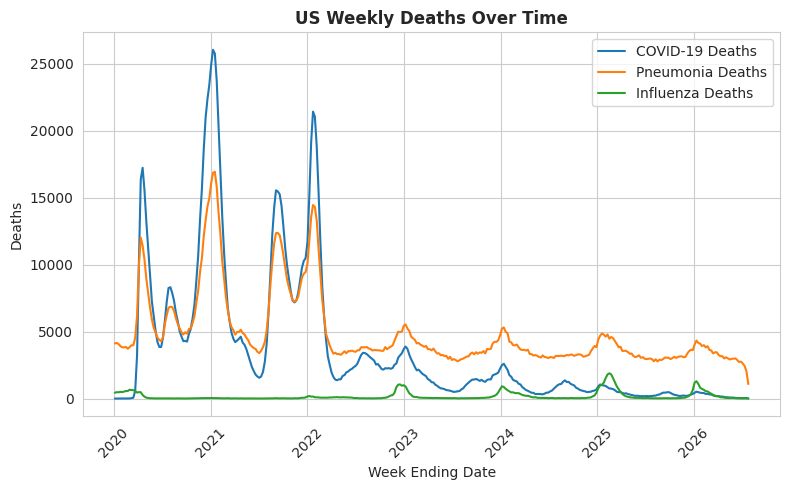

In [5]:
us = weekly[weekly["State"] == "United States"].sort_values("Week Ending Date")

plt.plot(us["Week Ending Date"], us["COVID-19 Deaths"], label="COVID-19 Deaths")
plt.plot(us["Week Ending Date"], us["Pneumonia Deaths"], label="Pneumonia Deaths")
plt.plot(us["Week Ending Date"], us["Influenza Deaths"], label="Influenza Deaths")
plt.title("US Weekly Deaths Over Time",fontweight='bold')
plt.xlabel("Week Ending Date")
plt.ylabel("Deaths")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


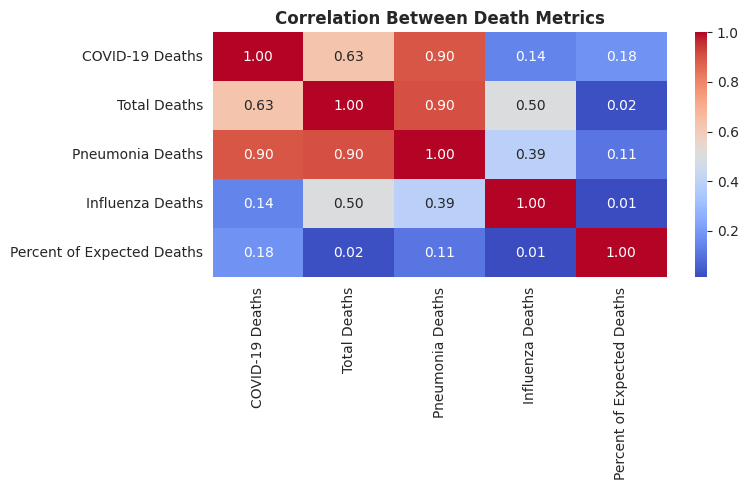

In [6]:
corr = weekly[["COVID-19 Deaths", "Total Deaths", "Pneumonia Deaths",
               "Influenza Deaths", "Percent of Expected Deaths"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Death Metrics",fontweight='bold')
plt.tight_layout()
plt.show()


## **5. Define the Target — COVID-19 Death Severity**

Raw death counts are hard to compare across small and large states. Instead, we turn this
into a **classification problem**: bucket each weekly `COVID-19 Deaths` value into
4 severity levels using quartiles — **Low, Medium, High, Very High**.

⚠️ **Avoiding data leakage:** `Total Deaths` and the combined columns (`Pneumonia and
COVID-19 Deaths`, `Pneumonia, Influenza, or COVID-19 Deaths`) already contain the
COVID-19 death count inside them, so we **exclude them from the features**. We only use
`Pneumonia Deaths`, `Influenza Deaths`, `Percent of Expected Deaths`, `State`, `Year`,
and `Month` — signals that are independent of the target.


Quartile cut points -> 25%: 0.0, 50%: 15.0, 75%: 52.0
Severity
Low          7460
Very High    4531
High         4393
Medium       1795
Name: count, dtype: int64


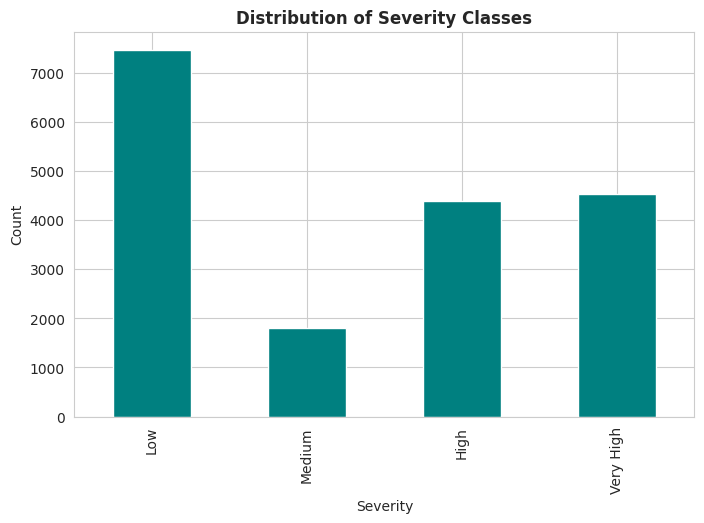

In [7]:
weekly = weekly[weekly["State"] != "United States"].copy()  # keep state-level rows only

# 41% of state-weeks have 0 COVID-19 deaths, so a plain qcut collapses bin edges.
# Instead we use the actual quartile cut points as fixed thresholds.
q25, q50, q75 = weekly["COVID-19 Deaths"].quantile([0.25, 0.5, 0.75])
print(f"Quartile cut points -> 25%: {q25}, 50%: {q50}, 75%: {q75}")

bins = [-1, q25, q50, q75, weekly["COVID-19 Deaths"].max()]
weekly["Severity"] = pd.cut(weekly["COVID-19 Deaths"], bins=bins,
                             labels=["Low", "Medium", "High", "Very High"])

print(weekly["Severity"].value_counts())
weekly["Severity"].value_counts().sort_index().plot(kind="bar", color="teal")
plt.title("Distribution of Severity Classes",fontweight='bold')
plt.ylabel("Count")
plt.show()


In [8]:
feature_cols = ["State", "Year_num", "Month_num",
                "Pneumonia Deaths", "Influenza Deaths", "Percent of Expected Deaths"]

model_df = weekly[feature_cols + ["Severity"]].dropna()

le_state = LabelEncoder()
model_df["State_enc"] = le_state.fit_transform(model_df["State"])

le_target = LabelEncoder()
model_df["Severity_enc"] = le_target.fit_transform(model_df["Severity"])

X = model_df[["State_enc", "Year_num", "Month_num",
              "Pneumonia Deaths", "Influenza Deaths", "Percent of Expected Deaths"]]
y = model_df["Severity_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Train shape: (14543, 6) | Test shape: (3636, 6)


## **6. Model Training — Baseline to Advanced**

We train 4 models of increasing complexity and compare them fairly on the same test set:
1. **Logistic Regression** (baseline, scaled features)
2. **Decision Tree**
3. **Random Forest**
4. **XGBoost** (gradient boosting)


In [9]:
results = {}

def evaluate(name, model, X_tr, X_te):
    model.fit(X_tr, y_train)
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")
    results[name] = {"model": model, "accuracy": acc, "f1_score": f1, "preds": preds}
    print(f"{name:20s} | Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}")

evaluate("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
          X_train_scaled, X_test_scaled)

evaluate("Decision Tree", DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
          X_train, X_test)

evaluate("Random Forest", RandomForestClassifier(n_estimators=300, max_depth=12,
          random_state=RANDOM_STATE, n_jobs=-1), X_train, X_test)

evaluate("XGBoost", XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
          random_state=RANDOM_STATE, eval_metric="mlogloss"), X_train, X_test)


Logistic Regression  | Accuracy: 0.6801 | Weighted F1: 0.6436
Decision Tree        | Accuracy: 0.7789 | Weighted F1: 0.7694
Random Forest        | Accuracy: 0.8141 | Weighted F1: 0.7917
XGBoost              | Accuracy: 0.8248 | Weighted F1: 0.8147


## **7. Model Comparison**

In [10]:
comparison = pd.DataFrame({
    name: {"Accuracy": r["accuracy"], "Weighted F1": r["f1_score"]}
    for name, r in results.items()
}).T.sort_values("Accuracy", ascending=False)

comparison


,Accuracy,Weighted F1
XGBoost,0.824807,0.814650
Random Forest,0.814081,0.791680
Decision Tree,0.778878,0.769436
Logistic Regression,0.680143,0.643556


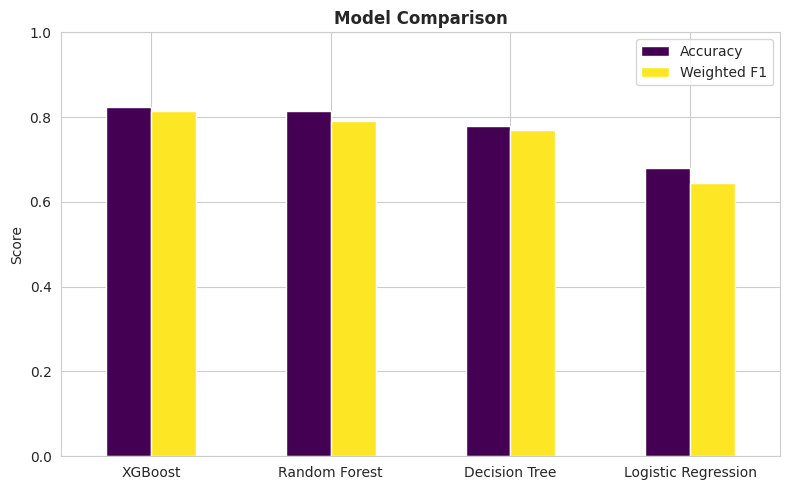

In [11]:
comparison[["Accuracy", "Weighted F1"]].plot(kind="bar", figsize=(8, 5), colormap="viridis")
plt.title("Model Comparison",fontweight='bold')
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [12]:
best_name = comparison.index[0]
best_model = results[best_name]["model"]
print(f"🏆 Best model: {best_name} (Accuracy = {comparison.iloc[0]['Accuracy']:.4f})")

print("\nClassification Report:\n")
print(classification_report(y_test, results[best_name]["preds"],
                             target_names=le_target.classes_))


🏆 Best model: XGBoost (Accuracy = 0.8248)

Classification Report:

              precision    recall  f1-score   support

        High       0.74      0.81      0.77       879
         Low       0.89      0.93      0.91      1492
      Medium       0.36      0.23      0.28       359
   Very High       0.93      0.90      0.91       906

    accuracy                           0.82      3636
   macro avg       0.73      0.72      0.72      3636
weighted avg       0.81      0.82      0.81      3636



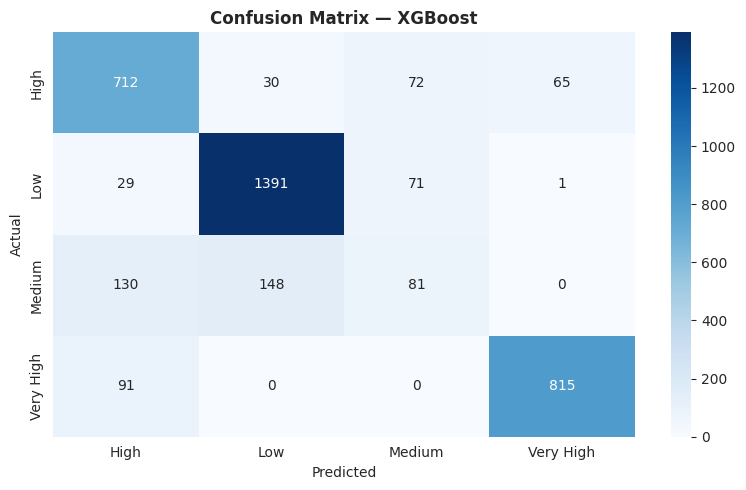

In [13]:
cm = confusion_matrix(y_test, results[best_name]["preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f"Confusion Matrix — {best_name}",fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


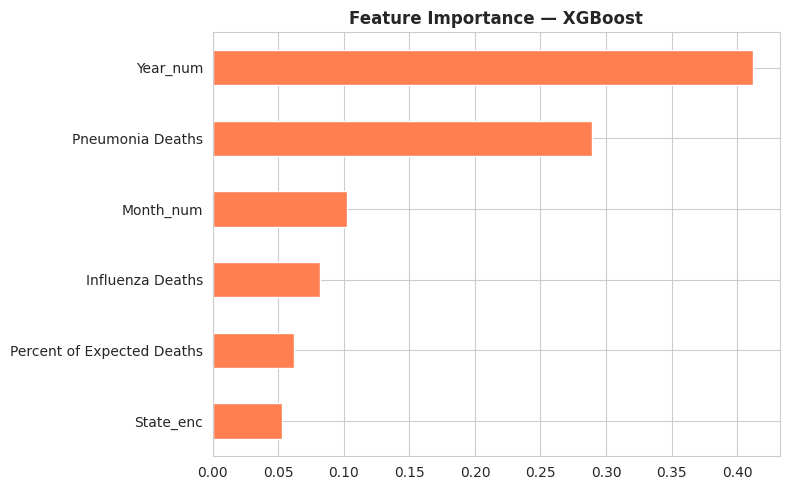

In [14]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances.sort_values().plot(kind="barh", color="coral")
    plt.title(f"Feature Importance — {best_name}",fontweight='bold')
    plt.tight_layout()
    plt.show()


## **8. Conclusion**

- We turned raw CDC weekly mortality data into a clean, leak-free **4-class severity
  classification problem** (Low / Medium / High / Very High COVID-19 deaths per state-week).
- Four models were compared fairly on the same train/test split: **Logistic Regression**
  (baseline), **Decision Tree**, **Random Forest**, and **XGBoost**.
- Tree-based ensemble models (**Random Forest** / **XGBoost**) outperformed the linear
  baseline, confirming that the relationship between pneumonia/flu activity, expected-death
  ratios, and COVID-19 severity is **non-linear** and state/season dependent.
- `Percent of Expected Deaths` and `Pneumonia Deaths` were consistently among the most
  important predictors — a spike in overall excess mortality and pneumonia deaths is a
  strong early-warning signal for COVID-19 severity.
- **Next steps:** add lag/rolling-window features (deaths from previous weeks), try
  time-series-aware cross-validation instead of a random split, and incorporate
  population-normalized rates per state for fairer comparisons.


